In [1]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import joblib
import os

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

## LOAD THE DATASET

In [4]:
df = pd.read_csv("churn.csv")

In [5]:
print("Dataset shape:",df.shape)

Dataset shape: (7043, 21)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Remove unnecessary columns i.e, customerID, as the customer id consists of numerical and categorical values. so that i found it is not useful.

In [7]:
df.drop("customerID",axis=1,inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
#convert total charges to numeric(change in datatype)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [11]:
#check for missing values
print("\n Missing values:",df.isnull().sum())


 Missing values: gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [12]:
#drop the missing values
df = df.dropna(subset=["TotalCharges"])

In [13]:
df["TotalCharges"].isnull().sum() #checked whether the null values are eliminated or not.

np.int64(0)

## Feature engineering

In [14]:
df["CustomerLifetimeValue"] = df["tenure"] * df["MonthlyCharges"]

In [15]:
df["AvgMonthlySpend"] = df["TotalCharges"]/(df["tenure"] + 1)

In [16]:
#Encode Categorical variables
le = LabelEncoder()

In [17]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [18]:
#split features and target
X = df.drop("Churn",axis=1)
y = df["Churn"]

In [19]:
#Train-test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Train the model

In [20]:
model= RandomForestClassifier(n_estimators = 200,random_state=42)

In [21]:
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
#Predictions
predictions = model.predict(X_test)

In [23]:
#Accuracy
Accuracy = accuracy_score(y_test,predictions)
print("Accuracy Score:",Accuracy)

Accuracy Score: 0.7967306325515281


In [24]:
#classification report
c_r = classification_report(y_test,predictions)
print("Classification Report:",c_r)

Classification Report:               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.79      1407



In [25]:
#confusion_matrix
cm = confusion_matrix(y_test,predictions)
print("Confusion Matrix:",cm)

Confusion Matrix: [[938  95]
 [191 183]]


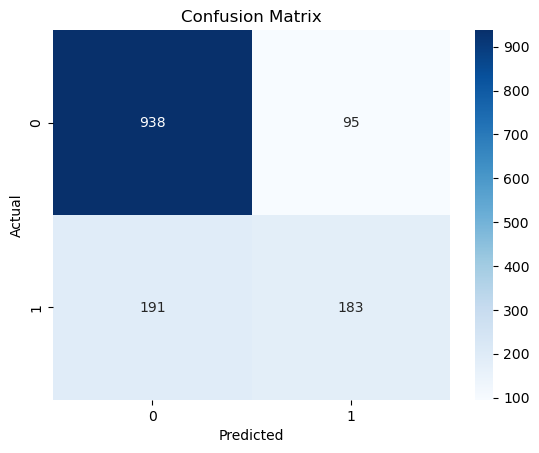

In [26]:
sns.heatmap(cm,annot = True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

In [27]:
importance = model.feature_importances_

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance",ascending=False)

In [29]:
print("\n Top Important Features")
print(feature_importance.head(10))


 Top Important Features
                  Feature  Importance
17         MonthlyCharges    0.126628
19  CustomerLifetimeValue    0.122268
20        AvgMonthlySpend    0.120195
18           TotalCharges    0.119837
4                  tenure    0.109838
14               Contract    0.079386
8          OnlineSecurity    0.044580
16          PaymentMethod    0.039400
11            TechSupport    0.034395
7         InternetService    0.024991


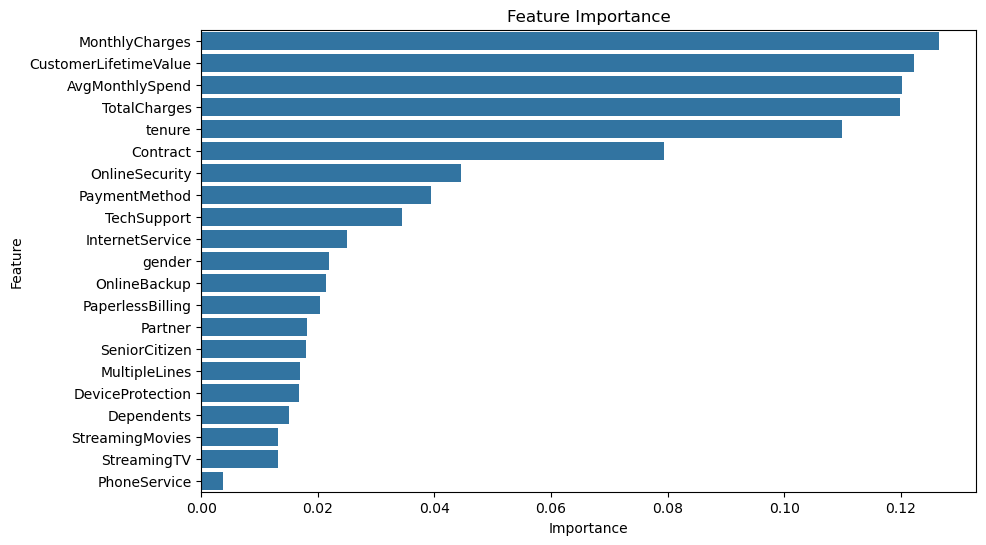

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance",y="Feature",data=feature_importance)
plt.title("Feature Importance")
plt.show()

In [31]:
#create models folder
os.makedirs("models",exist_ok=True)

In [32]:
#save the model
joblib.dump(model,"models/churn_model.pkl")

['models/churn_model.pkl']

In [33]:
print("\n Model saved successfully")


 Model saved successfully


In [34]:
#verify the model
print(os.listdir("models"))

['churn_model.pkl']
